# 🚗 Análisis de Siniestros y Detección de Patrones de Fraude en Seguros
**Herramientas:** Python · pandas · matplotlib · seaborn  
**Dataset:** Vehicle Insurance Claim Fraud Detection (Kaggle)  
**Autora:** Carla Maguiña Leston

## 📦 PASO 1 — Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 🔍 PASO 2 — Cargar y preparar el dataset

In [2]:
# Cargar dataset original
df = pd.read_csv('fraud_oracle.csv')

print(f'📊 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'\n📋 Columnas disponibles:')
print(df.columns.tolist())

📊 Dimensiones: 15420 filas x 33 columnas

📋 Columnas disponibles:
['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']


In [3]:
# Crear columna Fraude legible
df['Fraude'] = df['FraudFound_P'].map({1: 'Fraude', 0: 'Legítimo'})

# Renombrar columnas para mayor claridad
df = df.rename(columns={
    'VehicleCategory': 'IncidentType',
    'AgeOfVehicle': 'VehicleAge'
})

# Convertir VehiclePrice (texto) a número
def convertir_precio(valor):
    valor = str(valor).strip().lower()
    if 'more than 69000' in valor:
        return 69000
    elif 'less than 20000' in valor:
        return 15000
    elif 'to' in valor:
        partes = valor.replace(',', '').split('to')
        try:
            return (int(partes[0].strip()) + int(partes[1].strip())) / 2
        except:
            return None
    else:
        try:
            return int(valor.replace(',', ''))
        except:
            return None

df['ClaimAmount'] = df['VehiclePrice'].apply(convertir_precio)

print('✅ Dataset preparado correctamente')
print(f'Total siniestros: {len(df):,}')
print(f"Casos de fraude: {df['FraudFound_P'].sum():,} ({df['FraudFound_P'].mean()*100:.1f}%)")
print(f"\nDistribución ClaimAmount:")
print(df['ClaimAmount'].value_counts())

✅ Dataset preparado correctamente
Total siniestros: 15,420
Casos de fraude: 923 (6.0%)

Distribución ClaimAmount:
ClaimAmount
24500.0    8079
34500.0    3533
69000.0    2164
15000.0    1096
49500.0     461
64500.0      87
Name: count, dtype: int64


## 📊 PASO 3 — Análisis Exploratorio
### 3.1 — ¿Cuántos siniestros son fraude?

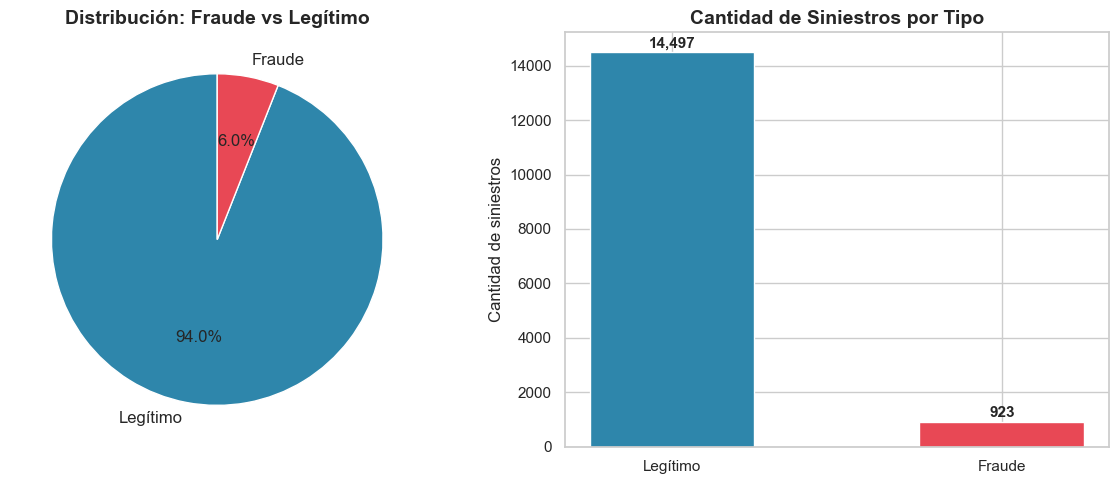

💾 Gráfico 1 guardado


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

conteo = df['Fraude'].value_counts()
colores = ['#2E86AB', '#E84855']

axes[0].pie(conteo, labels=conteo.index, autopct='%1.1f%%',
            colors=colores, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Distribución: Fraude vs Legítimo', fontsize=14, fontweight='bold')

bars = axes[1].bar(conteo.index, conteo.values, color=colores, edgecolor='white', width=0.5)
for bar, valor in zip(bars, conteo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{valor:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Cantidad de Siniestros por Tipo', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cantidad de siniestros')

plt.tight_layout()
plt.savefig('grafico_01_distribucion_fraude.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Gráfico 1 guardado')

### 3.2 — ¿Qué tipo de vehículo genera más reclamos?

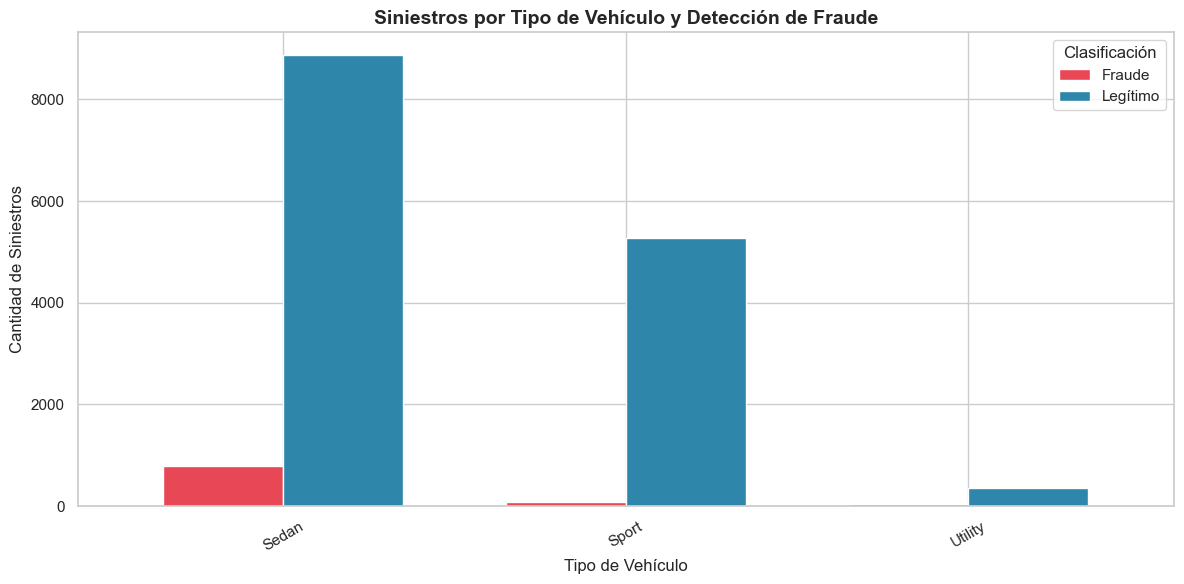

💾 Gráfico 2 guardado


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

tipo_fraude = df.groupby(['IncidentType', 'Fraude']).size().unstack(fill_value=0)
tipo_fraude.plot(kind='bar', ax=ax, color=['#E84855', '#2E86AB'], edgecolor='white', width=0.7)

ax.set_title('Siniestros por Tipo de Vehículo y Detección de Fraude', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Vehículo', fontsize=12)
ax.set_ylabel('Cantidad de Siniestros', fontsize=12)
ax.legend(title='Clasificación', fontsize=11)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('grafico_02_tipo_vehiculo.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Gráfico 2 guardado')

### 3.3 — ¿En qué mes ocurren más siniestros?

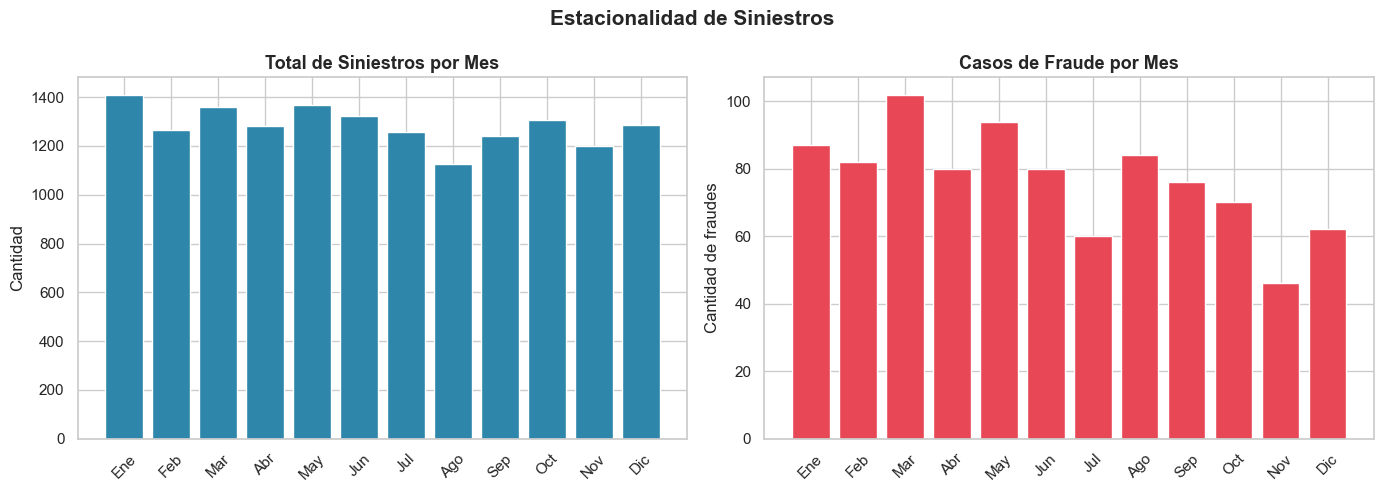

💾 Gráfico 3 guardado


In [6]:
orden_meses = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
nombres_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

siniestros_mes = df['Month'].value_counts().reindex(orden_meses, fill_value=0)
axes[0].bar(nombres_meses, siniestros_mes.values, color='#2E86AB', edgecolor='white')
axes[0].set_title('Total de Siniestros por Mes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

fraudes_mes = df[df['FraudFound_P']==1]['Month'].value_counts().reindex(orden_meses, fill_value=0)
axes[1].bar(nombres_meses, fraudes_mes.values, color='#E84855', edgecolor='white')
axes[1].set_title('Casos de Fraude por Mes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cantidad de fraudes')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Estacionalidad de Siniestros', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_03_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Gráfico 3 guardado')

### 3.4 — ¿El monto del reclamo varía entre fraude y casos legítimos?

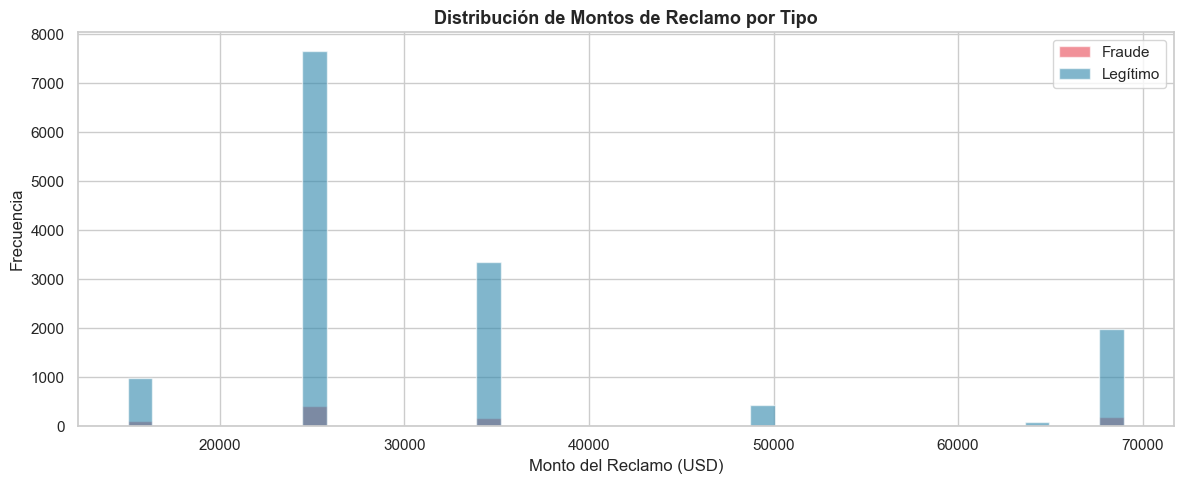

💾 Gráfico 4 guardado


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

colores_fraude = {'Fraude': '#E84855', 'Legítimo': '#2E86AB'}

for nombre, grupo in df.groupby('Fraude')['ClaimAmount']:
    ax.hist(grupo.dropna(), bins=40, alpha=0.6,
            label=nombre, color=colores_fraude[nombre], edgecolor='white')

ax.set_title('Distribución de Montos de Reclamo por Tipo', fontsize=13, fontweight='bold')
ax.set_xlabel('Monto del Reclamo (USD)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('grafico_04_montos.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Gráfico 4 guardado')

### 3.5 — Tasa de fraude por antigüedad del vehículo

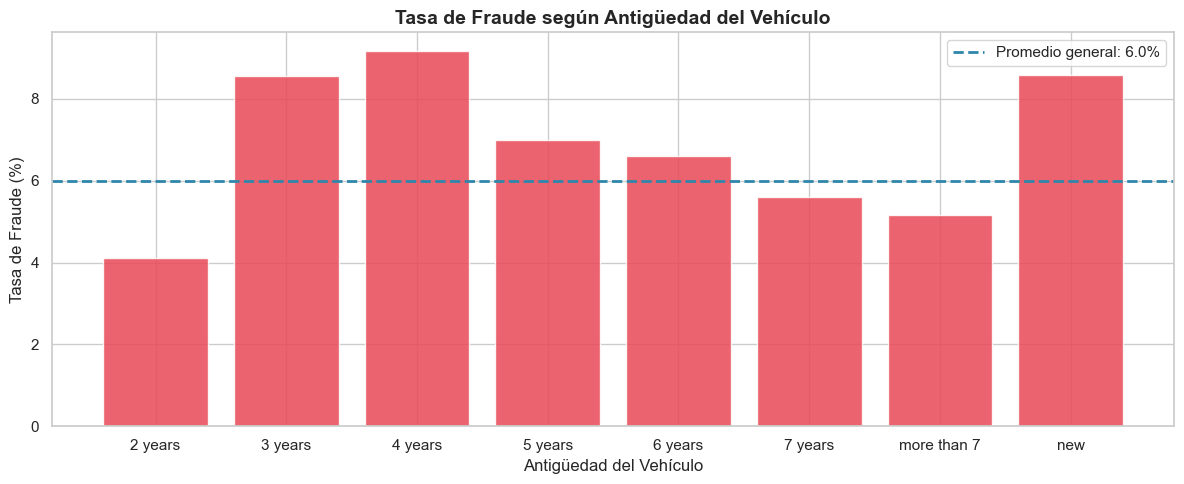

💾 Gráfico 5 guardado


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

fraude_por_anio = df.groupby('VehicleAge')['FraudFound_P'].mean() * 100
ax.bar(fraude_por_anio.index, fraude_por_anio.values, color='#E84855', edgecolor='white', alpha=0.85)

promedio = df['FraudFound_P'].mean() * 100
ax.axhline(promedio, color='#2E86AB', linestyle='--', linewidth=2,
           label=f'Promedio general: {promedio:.1f}%')

ax.set_title('Tasa de Fraude según Antigüedad del Vehículo', fontsize=14, fontweight='bold')
ax.set_xlabel('Antigüedad del Vehículo', fontsize=12)
ax.set_ylabel('Tasa de Fraude (%)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('grafico_05_antiguedad.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Gráfico 5 guardado')

### 3.6 — Factores asociados al fraude

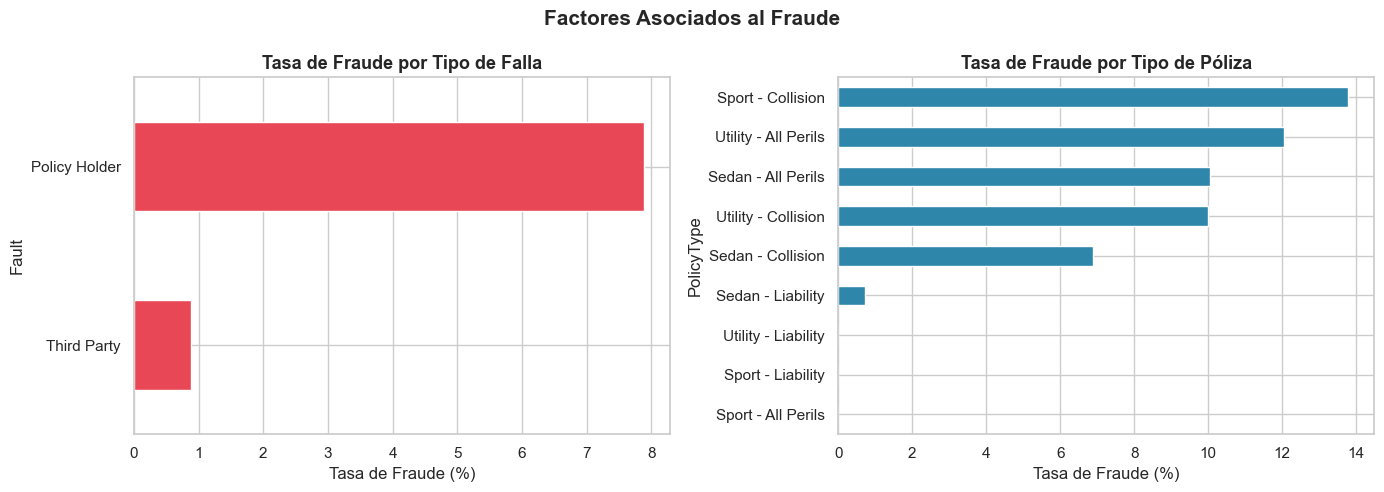

💾 Gráfico 6 guardado


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraude_falla = (df.groupby('Fault')['FraudFound_P'].mean() * 100).sort_values(ascending=True)
fraude_falla.plot(kind='barh', ax=axes[0], color='#E84855', edgecolor='white')
axes[0].set_title('Tasa de Fraude por Tipo de Falla', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tasa de Fraude (%)')

fraude_poliza = (df.groupby('PolicyType')['FraudFound_P'].mean() * 100).sort_values(ascending=True)
fraude_poliza.plot(kind='barh', ax=axes[1], color='#2E86AB', edgecolor='white')
axes[1].set_title('Tasa de Fraude por Tipo de Póliza', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tasa de Fraude (%)')

plt.suptitle('Factores Asociados al Fraude', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_06_factores.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Gráfico 6 guardado')

In [12]:
df['ClaimAmount'] = df['ClaimAmount'].astype('Int64')

## 📋 PASO 4 — Exportar datos limpios para Power BI

In [13]:
columnas_dashboard = ['Month', 'VehicleAge', 'IncidentType', 'Fault',
                      'PolicyType', 'ClaimAmount', 'FraudFound_P', 'Fraude']

columnas_disponibles = [c for c in columnas_dashboard if c in df.columns]
df_dashboard = df[columnas_disponibles].copy()

df_dashboard.to_csv('datos_limpios_para_powerbi.csv', index=False, encoding='utf-8-sig')

print(f'✅ Archivo exportado: datos_limpios_para_powerbi.csv')
print(f'   Filas: {len(df_dashboard):,}')
print(f'   Columnas: {list(df_dashboard.columns)}')

✅ Archivo exportado: datos_limpios_para_powerbi.csv
   Filas: 15,420
   Columnas: ['Month', 'VehicleAge', 'IncidentType', 'Fault', 'PolicyType', 'ClaimAmount', 'FraudFound_P', 'Fraude']


## ✅ PASO 5 — Conclusiones

In [14]:
total = len(df)
fraudes = df['FraudFound_P'].sum()
pct_fraude = fraudes/total*100
monto_fraude = df[df['FraudFound_P']==1]['ClaimAmount'].mean()
monto_legitimo = df[df['FraudFound_P']==0]['ClaimAmount'].mean()
mes_max = df['Month'].value_counts().idxmax()

print('=' * 55)
print('       RESUMEN EJECUTIVO DEL ANÁLISIS')
print('=' * 55)
print(f'  Total de siniestros analizados : {total:,}')
print(f'  Casos de fraude detectados     : {fraudes:,} ({pct_fraude:.1f}%)')
print(f'  Monto promedio — Fraude        : USD {monto_fraude:,.0f}')
print(f'  Monto promedio — Legítimo      : USD {monto_legitimo:,.0f}')
print(f'  Mes con más siniestros         : {mes_max}')
print('=' * 55)

       RESUMEN EJECUTIVO DEL ANÁLISIS
  Total de siniestros analizados : 15,420
  Casos de fraude detectados     : 923 (6.0%)
  Monto promedio — Fraude        : USD 35,461
  Monto promedio — Legítimo      : USD 33,199
  Mes con más siniestros         : Jan


In [15]:
print(df['PolicyType'].unique())

['Sport - Liability' 'Sport - Collision' 'Sedan - Liability'
 'Utility - All Perils' 'Sedan - All Perils' 'Sedan - Collision'
 'Utility - Collision' 'Utility - Liability' 'Sport - All Perils']


In [16]:
# Separar PolicyType en dos columnas
df[['TipoVehiculo', 'TipoPoliza']] = df['PolicyType'].str.split(' - ', expand=True)

print("TipoVehiculo:")
print(df['TipoVehiculo'].unique())
print("\nTipoPoliza:")
print(df['TipoPoliza'].unique())

TipoVehiculo:
['Sport' 'Sedan' 'Utility']

TipoPoliza:
['Liability' 'Collision' 'All Perils']


In [17]:
columnas_dashboard = ['Month', 'VehicleAge', 'TipoVehiculo', 'TipoPoliza', 
                      'Fault', 'ClaimAmount', 'FraudFound_P', 'Fraude']

df_dashboard = df[columnas_dashboard].copy()
df_dashboard.to_csv('datos_limpios_para_powerbi.csv', index=False, encoding='utf-8-sig')
print('✅ CSV exportado con columnas separadas')

✅ CSV exportado con columnas separadas


In [18]:
print(df['Year'].unique())
print(df['Year'].value_counts())

[1994 1995 1996]
Year
1994    6142
1995    5195
1996    4083
Name: count, dtype: int64


In [19]:
columnas_dashboard = ['Month', 'Year', 'DayOfWeek', 'Sex', 'Age',
                      'VehicleAge', 'TipoVehiculo', 'TipoPoliza', 
                      'Fault', 'ClaimAmount', 'FraudFound_P', 'Fraude']

df_dashboard = df[columnas_dashboard].copy()
df_dashboard.to_csv('datos_limpios_para_powerbi.csv', index=False, encoding='utf-8-sig')
print('✅ CSV exportado con columnas nuevas')
print(df_dashboard.columns.tolist())

✅ CSV exportado con columnas nuevas
['Month', 'Year', 'DayOfWeek', 'Sex', 'Age', 'VehicleAge', 'TipoVehiculo', 'TipoPoliza', 'Fault', 'ClaimAmount', 'FraudFound_P', 'Fraude']


In [20]:
print(df.columns.tolist())

['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'IncidentType', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'VehicleAge', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy', 'Fraude', 'ClaimAmount', 'TipoVehiculo', 'TipoPoliza']
